In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
# 1. LOAD RAW DATA

# Mount Google Drive to persist the dataset across sessions
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load the dataset that will be transformed into numerical format for modeling
data = pd.read_csv('/content/drive/MyDrive/bank_churn_project/bank_churn_data.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [4]:
# Load a second, untouched copy of the data with original text columns,
# kept separate for readable EDA visualizations
data_raw = pd.read_csv('/content/drive/MyDrive/bank_churn_project/bank_churn_data.csv')
data_raw.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [5]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Satisfaction Score  10000 non-null  int64  
 15  Card Type           10000 non-null  object 
 16  Point

In [6]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
data_raw.value_counts('Exited')

,count
Exited,
0,7962
1,2038


In [7]:
# Compare churn counts between male and female customers using a crosstab
gender_exited = pd.crosstab(data_raw['Gender'], data_raw['Exited'])
gender_exited

Exited,0,1
Gender,,
Female,3404,1139
Male,4558,899


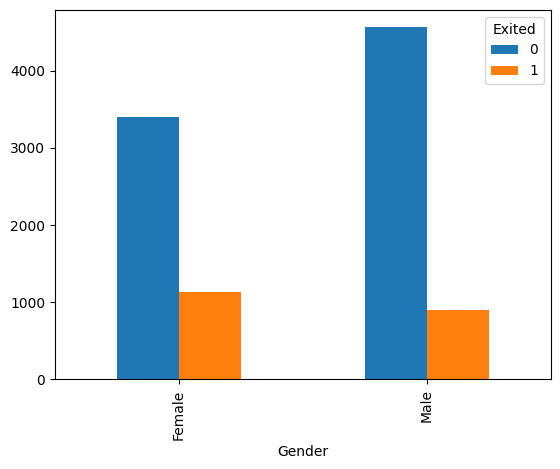

In [8]:
# Visualize churn distribution by gender using a bar chart
gender_exited.plot(kind='bar')
plt.show()

**Finding:** Female customers show a notably higher churn rate (25.1%)
compared to male customers (16.5%) — nearly 1.5x more likely to leave.
This suggests gender-specific retention strategies could be worth exploring.

In [9]:
# Compare churn counts across countries using a crosstab
geography_exited = pd.crosstab(data_raw['Geography'], data_raw['Exited'])
geography_exited

Exited,0,1
Geography,,
France,4203,811
Germany,1695,814
Spain,2064,413


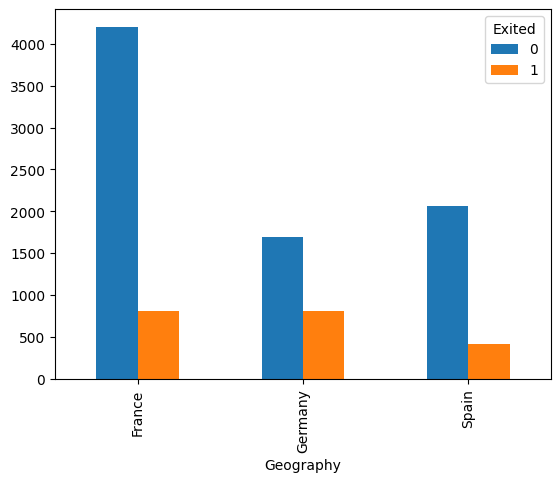

In [10]:
# Visualize churn distribution by country using a bar chart
geography_exited.plot(kind='bar')
plt.show()

**Finding**: German customers show a significantly higher churn rate (32.4%) compared to France (16.1%) and Spain (16.7%) — roughly double, despite Germany having far fewer total customers. This is a strong signal worth investigating further: possible explanations include stronger local competition, product-market fit issues, or differences in customer service quality in that region.

In [11]:
# Compare churn counts across card types using a crosstab
card_type_exited = pd.crosstab(data_raw['Card Type'], data_raw['Exited'])
card_type_exited

Exited,0,1
Card Type,,
DIAMOND,1961,546
GOLD,2020,482
PLATINUM,1987,508
SILVER,1994,502


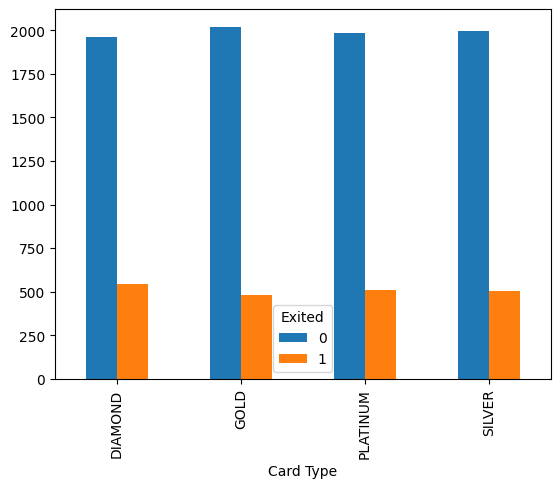

In [12]:
# Visualize churn distribution by card type using a bar chart
card_type_exited.plot(kind='bar')
plt.show()

**Finding:** Unlike Geography, Card Type shows minimal variation in churn rate
across categories (19.3%–21.8%), all close to the overall average (20.4%).
This suggests Card Type alone may not be a strong predictor of churn.

In [13]:
# Compare average age between churned and retained customers
data_raw.groupby('Exited')['Age'].mean()

,Age
Exited,
0,37.408063
1,44.835623


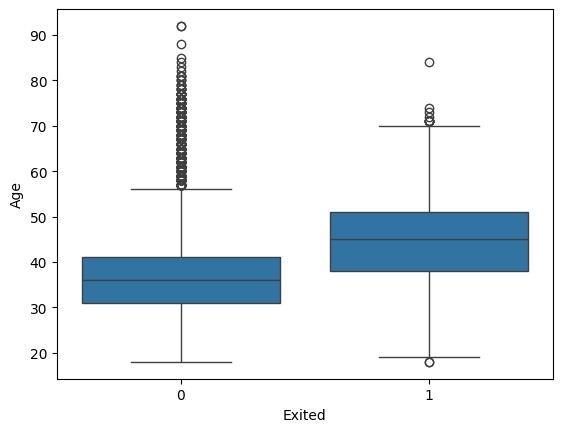

In [14]:
# Compare age distribution between churned and retained customers using a boxplot
sns.boxplot(x='Exited', y='Age', data=data_raw)
plt.show()

**Finding**: The boxplot reveals a clearer pattern than the average alone suggested — retained customers are typically in their 30s (interquartile range ~30-42), while churned customers are typically in their 40s to early 50s (interquartile range ~38-51), with minimal overlap between the two groups. This is a stronger signal than initially appeared: age band, not just average age, seems to meaningfully separate churned from retained customers.

In [15]:
# Compare average balance between churned and retained customers
data_raw.groupby('Exited')['Balance'].mean()

,Balance
Exited,
0,72742.750663
1,91109.476006


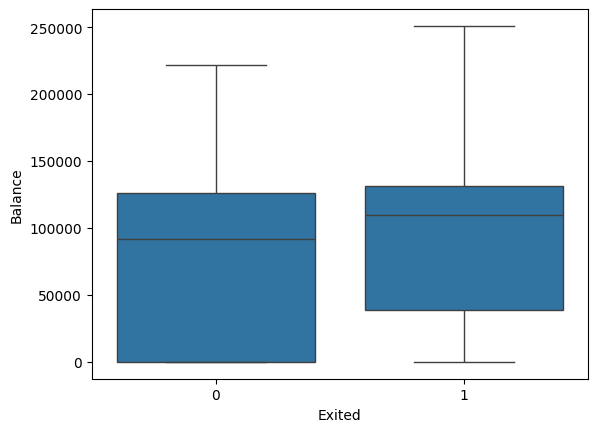

In [16]:
# Compare balance distribution between churned and retained customers using a boxplot
sns.boxplot(x='Exited', y='Balance', data=data_raw)
plt.show()

**Finding**: Balance shows more overlap between churned and retained customers than Age or Geography, suggesting it's a weaker standalone predictor — though churned customers do have a slightly higher median balance. Notably, over 25% of retained customers have a Balance of 0, likely reflecting inactive accounts; this may be worth exploring alongside IsActiveMember in later analysis.

In [17]:
# Compare average credit score between churned and retained customers
data_raw.groupby('Exited')['CreditScore'].mean()

,CreditScore
Exited,
0,651.837855
1,645.414622


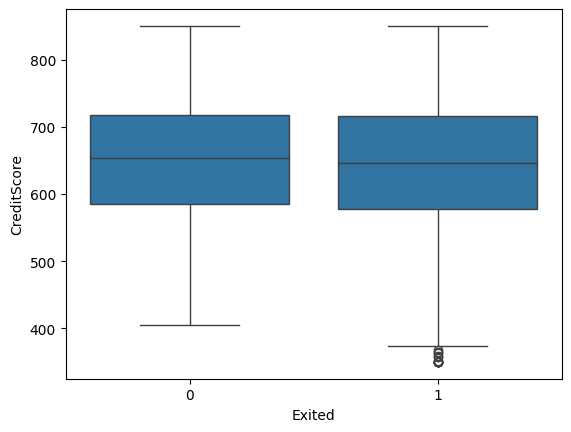

In [18]:
# Compare credit score distribution between churned and retained customers using a boxplot
sns.boxplot(x='Exited', y='CreditScore', data=data_raw)
plt.show()

**Finding**: CreditScore shows almost no meaningful difference between churned and retained customers (651.8 vs 645.4 average, near-identical boxplots). This suggests CreditScore is likely a weak predictor of churn on its own — customers don't appear to leave based on their credit standing.

In [19]:
# Compare average estiamted salary  between churned and retained customers
data_raw.groupby('Exited')['EstimatedSalary'].mean()

,EstimatedSalary
Exited,
0,99726.853141
1,101509.908783


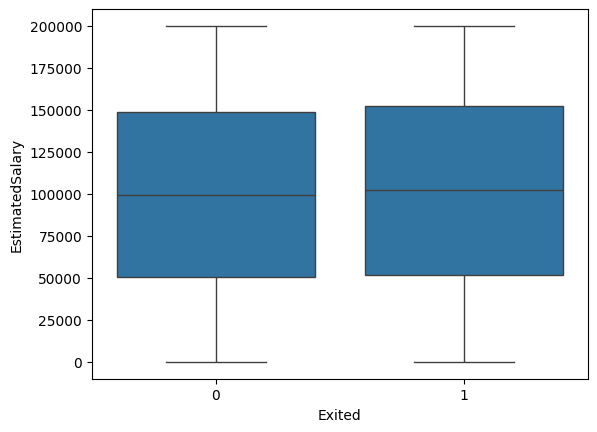

In [20]:
# Compare estiamted salary distribution between churned and retained customers using a boxplot
sns.boxplot(x='Exited', y='EstimatedSalary', data=data_raw)
plt.show()

**Finding**: EstimatedSalary shows virtually no difference between churned and retained customers (99,727 vs 101,510 average, nearly identical boxplots). Like CreditScore, salary alone does not appear to meaningfully predict churn — customers don't seem to leave based on how much they earn.

In [21]:
# Compare churn counts across number of products using a crosstab
products_exited = pd.crosstab(data_raw['NumOfProducts'], data_raw['Exited'])
products_exited

Exited,0,1
NumOfProducts,,
1,3675,1409
2,4241,349
3,46,220
4,0,60


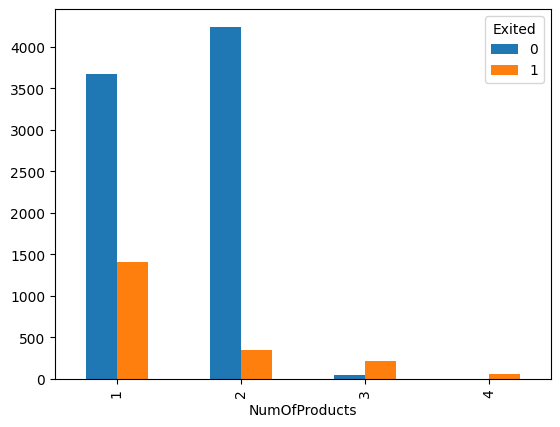

In [22]:
# Visualize churn distribution by number of products using a bar chart
products_exited.plot(kind='bar')
plt.show()

**Finding**: NumOfProducts shows the strongest signal found so far. Customers with 2 products have the lowest churn rate (7.6%), while churn spikes dramatically for customers with 3 products (82.7%) and 4 products (100%). This non-linear pattern suggests that having too many products isn't necessarily a sign of loyalty — it may instead reflect aggressive cross-selling, leading to customer frustration and eventual churn.

In [23]:
# Compare churn counts between active and inactive members using a crosstab
active_member_exited = pd.crosstab(data_raw['IsActiveMember'], data_raw['Exited'])
active_member_exited

Exited,0,1
IsActiveMember,,
0,3546,1303
1,4416,735


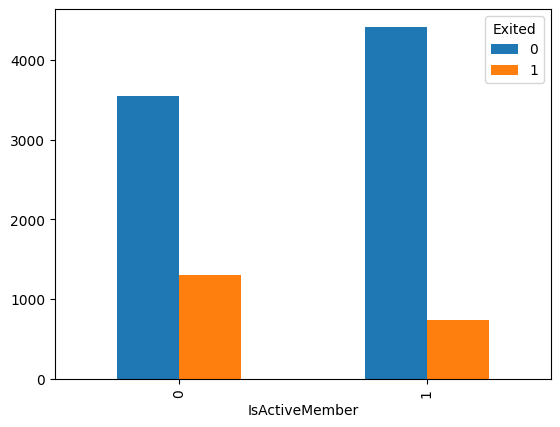

In [24]:
# Visualize churn distribution by active membership status using a bar chart
active_member_exited.plot(kind='bar')
plt.show()

**Finding**: Inactive members show a significantly higher churn rate (26.9%) compared to active members (14.3%) — nearly double. This aligns with business intuition: customers who engage less with the bank likely feel a weaker connection to it, making them more likely to leave. Combined with the NumOfProducts finding, this suggests engagement (not just product count) plays a key role in retention.

In [25]:
# Compare average tenure between churned and retained customers
data_raw.groupby('Exited')['Tenure'].mean()

,Tenure
Exited,
0,5.032781
1,4.934740


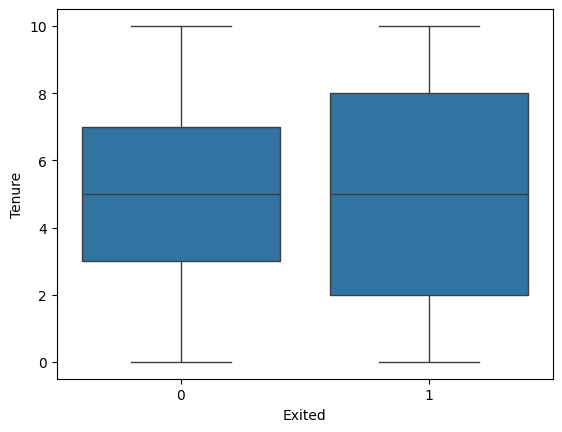

In [26]:
# Compare tenure distribution between churned and retained customers using a boxplot
sns.boxplot(x='Exited', y='Tenure', data=data_raw)
plt.show()

**Finding**: Tenure shows almost no difference between churned and retained customers (5.03 vs 4.93 years on average). Like CreditScore and EstimatedSalary, this suggests Tenure alone is a weak predictor of churn

In [27]:
# Compare churn counts between customers with and without a credit card using a crosstab
has_card_exited = pd.crosstab(data_raw['HasCrCard'], data_raw['Exited'])
has_card_exited

Exited,0,1
HasCrCard,,
0,2332,613
1,5630,1425


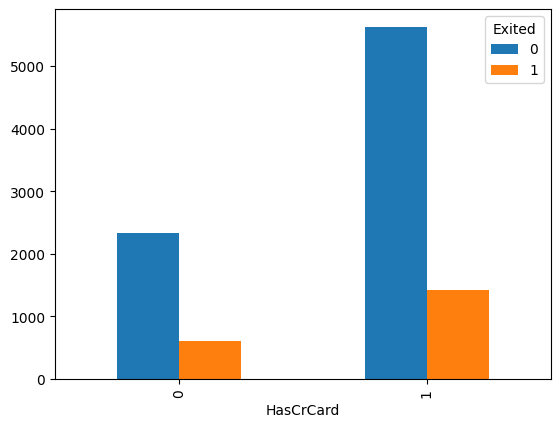

In [28]:
# Visualize churn distribution by credit card ownership using a bar chart
has_card_exited.plot(kind='bar')
plt.show()

**Finding**: HasCrCard shows virtually no difference in churn rate (20.8% without a card vs 20.2% with one) — essentially identical to the overall average. This is not a useful standalone predictor.

In [29]:
# Compare churn counts across satisfaction scores using a crosstab
satisfaction_exited = pd.crosstab(data_raw['Satisfaction Score'], data_raw['Exited'])
satisfaction_exited

Exited,0,1
Satisfaction Score,,
1,1545,387
2,1575,439
3,1641,401
4,1594,414
5,1607,397


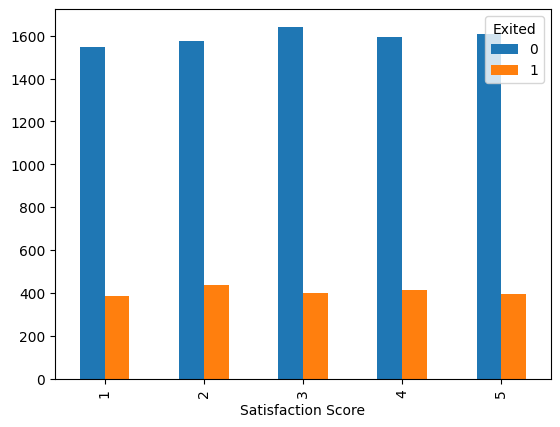

In [30]:
# Visualize churn distribution by satisfaction score using a bar chart
satisfaction_exited.plot(kind='bar')
plt.show()

**Finding**: Satisfaction Score shows no meaningful variation in churn rate across the 1-5 scale (all groups between ~20-22%). Surprisingly, this suggests that self-reported satisfaction does not predict actual churn behavior.

In [31]:
# Compare average points earned between churned and retained customers
data_raw.groupby('Exited')['Point Earned'].mean()

,Point Earned
Exited,
0,607.044084
1,604.448479


**Finding**: Point Earned shows no meaningful difference between churned and retained customers (607 vs 604 average). Like CreditScore and Tenure, this is not a useful standalone predictor of churn.

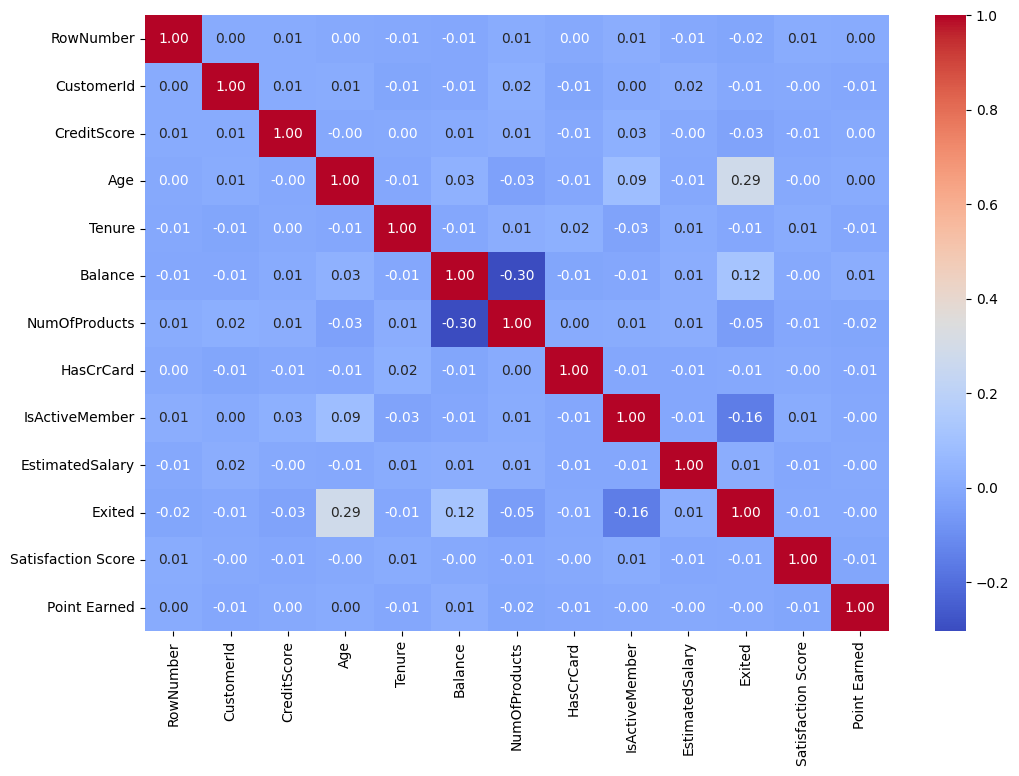

In [32]:
# Visualize correlations between all numerical variables using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

**Finding**: The correlation matrix confirms Age (0.29), IsActiveMember (-0.16), Balance (0.12), and Gender (0.11) as the variables with the strongest linear relationship to churn. However, an important limitation emerged: NumOfProducts shows almost no linear correlation (-0.05) despite being the strongest predictor found in the visual EDA (churn jumps from 7.6% at 2 products to 100% at 4 products). This is because Pearson correlation only captures linear relationships. NumOfProducts has a non-linear, U-shaped relationship with churn that correlation alone fails to detect. This highlights why visual, variable-by-variable EDA is essential and shouldn't be replaced by correlation analysis alone.

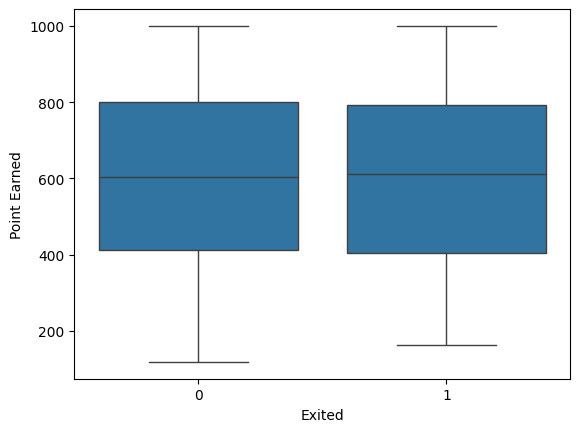

In [33]:
# Compare points earned distribution between churned and retained customers using a boxplot
sns.boxplot(x='Exited', y='Point Earned', data=data_raw)
plt.show()

In [34]:
# 3. FEATURE ENGINEERING / ENCODING

# Convert categorical text columns into numerical dummy variables,
# since ML models can only process numbers, not text
data = pd.get_dummies(data, columns=['Geography', 'Card Type'])
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Point Earned',
       'Geography_France', 'Geography_Germany', 'Geography_Spain',
       'Card Type_DIAMOND', 'Card Type_GOLD', 'Card Type_PLATINUM',
       'Card Type_SILVER'],
      dtype='object')

In [35]:
# Drop one dummy column per category to avoid redundant information
# (the dropped category can always be inferred from the remaining ones)
data = data.drop(columns=['Geography_Spain', 'Card Type_SILVER'])
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Point Earned',
       'Geography_France', 'Geography_Germany', 'Card Type_DIAMOND',
       'Card Type_GOLD', 'Card Type_PLATINUM'],
      dtype='object')

In [36]:
# Gender only has 2 categories, so a simple binary mapping is enough
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
data['Gender'].value_counts()

,count
Gender,
0,5457
1,4543


In [37]:
# Create a derived feature to capture the non-linear churn pattern found in EDA
data['has_3_or_more_products'] = (data['NumOfProducts'] >= 3).astype(int)
data['has_3_or_more_products'].value_counts()

,count
has_3_or_more_products,
0,9674
1,326


In [38]:
# Define features (X) and target (y), excluding identifiers and the target itself
X = data.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = data['Exited']
X.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score',
       'Point Earned', 'Geography_France', 'Geography_Germany',
       'Card Type_DIAMOND', 'Card Type_GOLD', 'Card Type_PLATINUM',
       'has_3_or_more_products'],
      dtype='object')

In [39]:
# 4. MODELING
# Split data into train/test sets, using stratify to preserve the 80/20 churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# Confirm class balance is preserved in the training set after stratified split
y_train.value_counts(normalize=True)
y_train.value_counts(normalize=True)

,proportion
Exited,
0,0.79625
1,0.20375


In [41]:
# Confirm class balance is preserved in the test set after stratified split
y_test.value_counts(normalize=True)

,proportion
Exited,
0,0.796
1,0.204


In [42]:
# Scale numerical features so all variables are on a comparable range,
# since Logistic Regression is sensitive to differences in feature scale.
# Fit the scaler only on training data to avoid data leakage into the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# Train a Logistic Regression model as a baseline classifier
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train_scaled, y_train)
log_reg_preds = log_reg_model.predict(X_test_scaled)

In [44]:
# Evaluate Logistic Regression using multiple metrics
print("Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Precision:", precision_score(y_test, log_reg_preds))
print("Recall:", recall_score(y_test, log_reg_preds))
print("F1:", f1_score(y_test, log_reg_preds))

Accuracy: 0.8405
Precision: 0.7129186602870813
Recall: 0.36519607843137253
F1: 0.4829821717990275


In [45]:
# Retrain Logistic Regression with class_weight='balanced' to address class imbalance,
# giving more importance to correctly identifying churned customers
log_reg_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg_balanced.fit(X_train_scaled, y_train)
log_reg_balanced_preds = log_reg_balanced.predict(X_test_scaled)

In [46]:
# Evaluate the balanced Logistic Regression model
print("Accuracy:", accuracy_score(y_test, log_reg_balanced_preds))
print("Precision:", precision_score(y_test, log_reg_balanced_preds))
print("Recall:", recall_score(y_test, log_reg_balanced_preds))
print("F1:", f1_score(y_test, log_reg_balanced_preds))

Accuracy: 0.771
Precision: 0.4632352941176471
Recall: 0.7720588235294118
F1: 0.5790441176470589


In [47]:
# Train a Random Forest model with balanced class weights
rf_model_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model_balanced.fit(X_train, y_train)
rf_balanced_preds = rf_model_balanced.predict(X_test)

In [48]:
# Evaluate the balanced Random Forest model
print("Accuracy:", accuracy_score(y_test, rf_balanced_preds))
print("Precision:", precision_score(y_test, rf_balanced_preds))
print("Recall:", recall_score(y_test, rf_balanced_preds))
print("F1:", f1_score(y_test, rf_balanced_preds))

Accuracy: 0.864
Precision: 0.7956521739130434
Recall: 0.4485294117647059
F1: 0.5736677115987461


In [49]:
# Train a Random Forest model without balanced class weights
rf_model_default = RandomForestClassifier(random_state=42)
rf_model_default.fit(X_train, y_train)
rf_default_preds = rf_model_default.predict(X_test)

In [50]:
# Evaluate the default Random Forest model
print("Accuracy:", accuracy_score(y_test, rf_default_preds))
print("Precision:", precision_score(y_test, rf_default_preds))
print("Recall:", recall_score(y_test, rf_default_preds))
print("F1:", f1_score(y_test, rf_default_preds))

Accuracy: 0.869
Precision: 0.7991803278688525
Recall: 0.47794117647058826
F1: 0.598159509202454


In [51]:
# Train an XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [52]:
# Evaluate the XGBoost model
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1:", f1_score(y_test, xgb_preds))

Accuracy: 0.8515
Precision: 0.6843853820598007
Recall: 0.5049019607843137
F1: 0.5811001410437235


In [53]:
# Train XGBoost with scale_pos_weight to address class imbalance
xgb_model_balanced = XGBClassifier(random_state=42, scale_pos_weight=4)
xgb_model_balanced.fit(X_train, y_train)
xgb_balanced_preds = xgb_model_balanced.predict(X_test)

In [54]:
# Evaluate the balanced XGBoost model
print("Accuracy:", accuracy_score(y_test, xgb_balanced_preds))
print("Precision:", precision_score(y_test, xgb_balanced_preds))
print("Recall:", recall_score(y_test, xgb_balanced_preds))
print("F1:", f1_score(y_test, xgb_balanced_preds))

Accuracy: 0.829
Precision: 0.5726872246696035
Recall: 0.6372549019607843
F1: 0.6032482598607889


In [55]:
# Define hyperparameter grid to search for the best XGBoost configuration
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

In [56]:
# Search for the best combination of hyperparameters using cross-validation,
# optimizing for F1 score since we care about balancing precision and recall
grid_search = GridSearchCV(
    XGBClassifier(random_state=42, scale_pos_weight=4),
    param_grid,
    scoring='f1',
    cv=3
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score (cross-validation):", grid_search.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Best F1 score (cross-validation): 0.6029531447799913


In [57]:
# Get predictions from the best model found by GridSearchCV
xgb_tuned_preds = grid_search.predict(X_test)

# Evaluate the tuned XGBoost model
print("Accuracy:", accuracy_score(y_test, xgb_tuned_preds))
print("Precision:", precision_score(y_test, xgb_tuned_preds))
print("Recall:", recall_score(y_test, xgb_tuned_preds))
print("F1:", f1_score(y_test, xgb_tuned_preds))

Accuracy: 0.83
Precision: 0.5677290836653387
Recall: 0.6985294117647058
F1: 0.6263736263736264


In [58]:
# Train a Gradient Boosting model for comparison against XGBoost
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

In [59]:
# Evaluate the Gradient Boosting model
print("Accuracy:", accuracy_score(y_test, gb_preds))
print("Precision:", precision_score(y_test, gb_preds))
print("Recall:", recall_score(y_test, gb_preds))
print("F1:", f1_score(y_test, gb_preds))

Accuracy: 0.8705
Precision: 0.7811320754716982
Recall: 0.5073529411764706
F1: 0.6151560178306092


In [60]:
# Train a Naive Bayes model - a fundamentally different approach based on probability,
# useful to see how it performs given its assumption of feature independence
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

In [61]:
# Evaluate the Naive Bayes model
print("Accuracy:", accuracy_score(y_test, nb_preds))
print("Precision:", precision_score(y_test, nb_preds))
print("Recall:", recall_score(y_test, nb_preds))
print("F1:", f1_score(y_test, nb_preds))

Accuracy: 0.7875
Precision: 0.373134328358209
Recall: 0.061274509803921566
F1: 0.10526315789473684


In [62]:
# Summarize all model results in a single comparison table
results_summary = pd.DataFrame({
    'Model': ['Log Reg Original', 'Log Reg Balanced', 'RF Balanced', 'RF Default',
              'XGBoost Default', 'XGBoost Balanced', 'XGBoost Tuned', 'SVM',
              'Gradient Boosting', 'Naive Bayes'],
    'Accuracy': [0.84, 0.77, 0.86, 0.87, 0.85, 0.83, 0.83, 0.78, 0.87, 0.79],
    'Precision': [0.71, 0.46, 0.80, 0.80, 0.68, 0.57, 0.57, 0.48, 0.78, 0.37],
    'Recall': [0.37, 0.77, 0.45, 0.48, 0.50, 0.64, 0.70, 0.75, 0.51, 0.06],
    'F1': [0.48, 0.58, 0.57, 0.60, 0.58, 0.60, 0.63, 0.58, 0.615, 0.11]
})

results_summary = results_summary.sort_values('F1', ascending=False)
results_summary

,Model,Accuracy,Precision,Recall,F1
6,XGBoost Tuned,0.83,0.57,0.70,0.630
8,Gradient Boosting,0.87,0.78,0.51,0.615
3,RF Default,0.87,0.80,0.48,0.600
5,XGBoost Balanced,0.83,0.57,0.64,0.600
7,SVM,0.78,0.48,0.75,0.580
1,Log Reg Balanced,0.77,0.46,0.77,0.580
4,XGBoost Default,0.85,0.68,0.50,0.580
2,RF Balanced,0.86,0.80,0.45,0.570
0,Log Reg Original,0.84,0.71,0.37,0.480
9,Naive Bayes,0.79,0.37,0.06,0.110


In [63]:
# Generate confusion matrix for the final tuned XGBoost model
confusion_matrix(y_test, xgb_tuned_preds)

array([[1375,  217],
       [ 123,  285]])

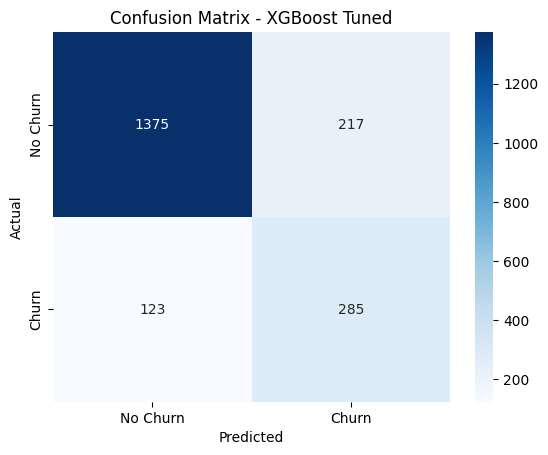

In [64]:
# Visualize the confusion matrix as a heatmap
cm = confusion_matrix(y_test, xgb_tuned_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost Tuned')
plt.show()

**Finding**: The confusion matrix shows that out of 408 customers who actually churned, the model correctly identified 285 (70% recall), while 123 went undetected. It also flagged 217 customers as high-risk who ultimately stayed — a reasonable trade-off, since the cost of a false alarm (an unnecessary retention offer) is typically much lower than the cost of losing a customer without any intervention. This makes the model practically useful for a bank: it prioritizes catching real churners, even at the expense of some false positives.

In [65]:
# 5. FEATURE IMPORTANCE
# Extract feature importance scores from the best XGBoost model found by GridSearchCV
importances = grid_search.best_estimator_.feature_importances_
importances

array([0.03173866, 0.0476544 , 0.12715141, 0.02796232, 0.05526601,
       0.23053738, 0.02440529, 0.15640762, 0.03080505, 0.03018582,
       0.03206435, 0.04214481, 0.0732442 , 0.02956278, 0.03090508,
       0.02996487, 0.        ], dtype=float32)

In [66]:
# Combine feature names with their importance scores and sort from most to least important
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
feature_importance_df

,feature,importance
5,NumOfProducts,0.230537
7,IsActiveMember,0.156408
2,Age,0.127151
12,Geography_Germany,0.073244
4,Balance,0.055266
1,Gender,0.047654
11,Geography_France,0.042145
10,Point Earned,0.032064
0,CreditScore,0.031739
14,Card Type_GOLD,0.030905


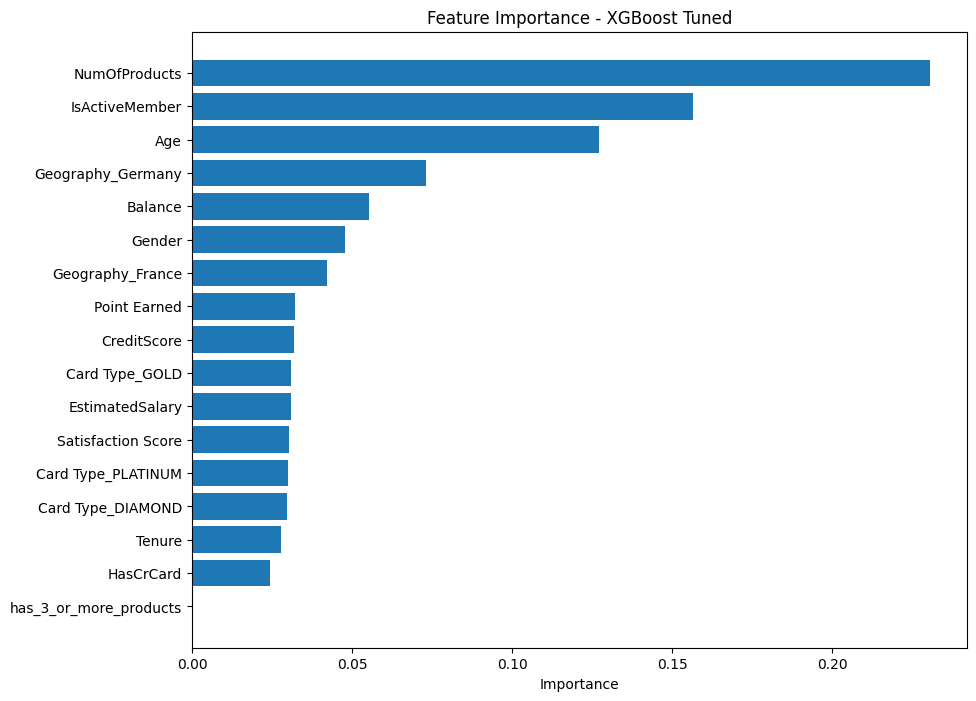

In [67]:
# Visualize feature importance from the tuned XGBoost model
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - XGBoost Tuned')
plt.gca().invert_yaxis()
plt.show()

**Finding**: Feature importance from the tuned XGBoost model closely aligns with the visual EDA findings — NumOfProducts (0.23), IsActiveMember (0.16), Age (0.13), and Geography_Germany (0.07) rank as the top predictors, matching the strongest signals identified earlier through crosstabs and boxplots. This cross-validates the EDA: the patterns visually identified before modeling turned out to be exactly what the model learned to rely on. Interestingly, the derived feature has_3_or_more_products received zero importance — since XGBoost, being a non-linear model, already captures the non-linear churn pattern directly from the original NumOfProducts column, making the derived feature redundant for this particular model (though it would likely add value for a linear model like Logistic Regression).

# ***Business Recommendations***

**1. NumOfProducts**

Reconsider cross-selling strategies for customers approaching 3+ products — the data suggests aggressive upselling beyond 2 products may correlate with dissatisfaction rather than loyalty. Consider proactive account check-ins for customers who recently acquired a 3rd or 4th product, focusing on service quality rather than additional sales.

**2. IsActiveMember**

Implement re-engagement campaigns for inactive members — such as personalized notifications, small incentives for resuming regular account activity, or simplified digital banking features that reduce friction. Since inactivity is one of the strongest churn predictors, early intervention (e.g., after 30-60 days of inactivity) could meaningfully reduce attrition before the customer disengages completely.

**3. Age**

Investigate whether product offerings adequately serve customers in their 40s-50s — this age group may have different financial priorities than younger customers, such as mortgages, retirement planning, wealth management, or estate planning. If the bank's current offerings skew toward younger, digital-first customers, tailored products or advisory services for this segment could help improve retention.

**4. Geography (Germany)**

Conduct further investigation into the German market specifically — the data shows a churn rate roughly double that of France and Spain, but doesn't reveal the underlying cause. Possible factors worth exploring include local competition, cultural fit of products, or regional customer service quality. A market-specific survey or focus group could help identify the root cause before designing targeted retention strategies.